# Bays (2014) Figure 3 — Attention as Selective Recruitment

**Goal.** Reproduce Bays Fig 3 (cued/uncued error distributions, variance, kurtosis) using a **biologically motivated alternative** to gain modulation: cueing recruits the subpopulation of neurons most informative about the cued location, and that subpopulation does *all* the work — encoding the cued and uncued items alike.

---

## What changed from the previous α-based notebook

The previous version implemented Bays-style attention as a multiplicative log-space gain α applied to the cued location's contribution to each neuron's drive. Every one of the M neurons participated in encoding every item; α just biased the activity vector so the cued contribution survived divisive normalization.

**This notebook replaces that mechanism entirely.** There is no α. Instead:

1. The cue identifies a location (by convention, location 0).
2. We rank all M neurons by their **sharpness at location 0** — concretely, the variance of their tuning curve f_{n,0}(θ) along the orientation grid. Neurons with sharper (narrower) tuning have larger swings and so larger variance; neurons with broad, flat tuning have small variance.
3. The top **M/l** neurons (where l is the set size) are the *recruited subpopulation* I_c. Every other neuron is silent for the trial — they are not in the picture at all.
4. The recruited neurons compute their pre-DN response normally, multiplying tuning across **all l locations** (cued and uncued):

$$r_n^{\text{pre}}(S, \theta) = \prod_{k \in S} g_{n,k}(\theta_k), \quad n \in I_c$$

5. DN, Poisson noise, and ML decoding all operate on this restricted set.

## Why this is a meaningful change

Under gain modulation, the cued readout listens to all neurons, just with the sharp ones contributing more. Under recruitment, the cued readout listens **only** to sharp neurons, and the broad ones are excluded entirely. This is biased competition rather than gain modulation — Desimone & Duncan rather than Reynolds & Heeger.

The cued item gets the best of two worlds: it is encoded by neurons selected for being sharp *at its location*. Uncued items are encoded by the same recruited neurons, but those neurons' tuning at uncued locations is whatever the GP happened to sample — broad on average, since they were selected for sharpness elsewhere. So the cost of attention is borne by the unattended items as a *quality of representation* loss, not as a gain reduction.

A clean side-effect: the recruitment fraction 1/l also shrinks the active population as set size grows, automatically introducing an additional capacity bottleneck on top of DN.


## Imports

Same imports as the original notebook. We reuse `Population` for construction and `ml_decode` / circular statistics from `core.decoder.ml_decoder`. We do **not** use `Population.run_trials` here — that function operates on the full population, and the whole point of this notebook is to restrict to the recruited subset.


In [7]:
import sys
from pathlib import Path
PROJECT_ROOT = str(Path.cwd().parents[1])
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
from scipy.special import logsumexp, i0

from core.population import Population
from core.decoder.ml_decoder import (
    decode as ml_decode,
    circular_error,
    circular_variance_fisher,
    circular_kurtosis_fisher,
)

print(f'Project root: {PROJECT_ROOT}')


Project root: /Users/yashbharti/Desktop/Research/mphil/mixed_selectivity_pfc_v0.1/equivalence_model_v0.1


## von Mises KDE for plotting

Identical to the original notebook. A circular KDE using von Mises kernels avoids the boundary artefacts that a Gaussian KDE would produce at ±π. Used only for the smooth density curves in panel a; all variance and kurtosis statistics are computed directly from raw errors using Fisher (1995) formulas via `circular_variance_fisher` / `circular_kurtosis_fisher`.

This is the only function defined in the notebook — it's a plotting utility called many times across the figure, so a function makes sense. The recruitment and trial logic are written out inline below.


In [8]:
def vonmises_kde(data, eval_points, kappa):
    '''Circular KDE using von Mises kernels (no boundary artefacts at +/- pi).'''
    data = np.asarray(data); eval_points = np.asarray(eval_points)
    n = len(data)
    diff = eval_points[:, None] - data[None, :]
    log_norm = np.log(2.0 * np.pi * float(i0(kappa)))
    log_kernels = kappa * np.cos(diff) - log_norm
    return np.exp(logsumexp(log_kernels, axis=1) - np.log(n))

KAPPA_KDE = 25.0


## Configuration

Changes from the previous notebook:

- **Soft gain instead of hard mask.** We compute $r^{\text{pre}}$ over the **full** population of $M$ neurons. Recruitment now means the top $M/l$ sharpest-at-location-0 neurons get their pre-DN drive multiplied by $\alpha$; everyone else is left at $\times 1$. The hard-mask limit corresponds to $\alpha \to \infty$.
- **DN over the full $M$.** The denominator $D = \sigma^2 + \frac{1}{M}\sum_n r^{\text{pre}}_n$ averages over *all* $M$ neurons, not just the recruited subset. The consequence is that, holding $\gamma$ fixed, the post-DN rate per recruited neuron is roughly $l\times$ smaller than in the previous hard-mask version where DN normalised by $M/l$. Equivalently: the total post-DN activity budget is $\gamma M$ distributed across all $M$ neurons, and the recruited subset captures a share of it proportional to $\alpha r^{\text{pre}}_{\text{recruited}} / (\alpha r^{\text{pre}}_{\text{recruited}} + r^{\text{pre}}_{\text{rest}})$. This is a different physical claim from the recruitment-pool-only DN of the previous notebook and is worth keeping in mind when comparing variance magnitudes.
- **`M = 1000`** kept the same so the recruited subset $M/l \in \{500, 250, 125\}$ is substantial.
- **`N_TRIALS`** is the per-condition trial count.
- The Bays parametric values for $\omega$ and $\gamma$ are unchanged so per-neuron activity scale is comparable.
- **`ALPHA`** is the new free parameter — set to a single value here, but the cell is structured so you can sweep it.


In [9]:
M = 1000             # neurons (full pool -- DN normalises over all of them)
N_THETA = 128        # orientation grid resolution
N_TRIALS = 5000      # trials per (set_size, probe condition)
T_D = 0.1
SIGMA_SQ = 1e-6

# Bays (2014) fitted parameters -- omega = lambda^2, so lambda = sqrt(omega)
OMEGA_BAYS = 0.52
GAMMA_BAYS = 119.0
LAMBDA_BASE = np.sqrt(OMEGA_BAYS)
GAMMA = GAMMA_BAYS / M

SET_SIZES = [2, 4, 8]
CUE_RATIO = 3.0      # cued item probed 3x as often as each individual uncued item
SEED = 42

# --- Soft-recruitment gain ---
# alpha > 1: recruited neurons (top M/l sharpest at loc 0) get boosted drive.
# alpha = 1: no attention (sanity check -- cued should ~= uncued).
# alpha -> inf: approaches the hard-mask recruitment limit.
ALPHA = 10.0

print(f'M={M}, N_THETA={N_THETA}, lambda={LAMBDA_BASE:.4f} (omega = lambda^2 = {LAMBDA_BASE**2:.3f})')
print(f'gamma={GAMMA:.4f} Hz/neuron, total gamma*M={GAMMA*M:.1f} Hz')
print(f'alpha={ALPHA} (recruited multiplier; non-recruited stay at x1)')
print(f'Recruitment counts (M/l):')
for N in SET_SIZES:
    p_c = CUE_RATIO / (CUE_RATIO + N - 1)
    print(f'  l={N}: |I_c| = {M // N} neurons, p_cued = {p_c:.3f}')


M=1000, N_THETA=128, lambda=0.7211 (omega = lambda^2 = 0.520)
gamma=0.1190 Hz/neuron, total gamma*M=119.0 Hz
alpha=10.0 (recruited multiplier; non-recruited stay at x1)
Recruitment counts (M/l):
  l=2: |I_c| = 500 neurons, p_cued = 0.750
  l=4: |I_c| = 250 neurons, p_cued = 0.500
  l=8: |I_c| = 125 neurons, p_cued = 0.300


## Generate the population

A single `Population` is constructed once and reused across all set sizes. We use the GP tuning mode with `lengthscale_variability=0.5` — this **must be non-zero** for recruitment to do anything interesting. With zero variability every neuron has the same lengthscale at every location, every neuron has the same tuning-curve variance at location 0, the "top M/l sharpest" set is just an arbitrary subset, and the whole mechanism collapses to "use a random M/l of neurons." The variability is what gives the recruitment criterion something to select on.

We also print the distribution of sharpness scores at location 0 (variance of f along the θ axis) as a sanity check — there should be a meaningful spread between the sharpest and broadest neurons, otherwise recruitment is doing nothing.


In [10]:
max_locs = max(SET_SIZES)
pop = Population(
    M=M, n_theta=N_THETA, omega=OMEGA_BAYS,
    tuning_type='gp', n_locations=max_locs, seed=SEED,
    lengthscale_variability=0.5, gain_variability=0.0
)
print(pop)
print(f'f shape: {pop.f.shape}')

# Sanity check: distribution of sharpness scores at location 0
sharp0 = pop.f[:, 0, :].var(axis=1)
print(f'Sharpness at location 0 -- min: {sharp0.min():.4f}, '
      f'median: {np.median(sharp0):.4f}, max: {sharp0.max():.4f}')
print(f'Top/bottom sharpness ratio: {sharp0.max() / max(sharp0.min(), 1e-9):.1f}x')


Population(N=1000, L=8, n_theta=128, tuning='gp', omega=0.52)
f shape: (1000, 8, 128)
Sharpness at location 0 -- min: 0.0196, median: 0.6474, max: 3.9076
Top/bottom sharpness ratio: 199.6x


## Recruit + scale + encode + decode, inline

Pipeline below. The structure is:

**Outer loop over set sizes l ∈ {2, 4, 8}.** For each l:

1. **Identify the recruited set.** Compute per-neuron sharpness at location 0 as `pop.f[:, 0, :].var(axis=1)`. Sort descending. Take the top `M_recruit = M // l` indices. Build a boolean mask `recruited_mask` of length $M$.

2. **Compute $r^{\text{pre}}$ on the full population** (not just the recruited subset). Shape `(M, N_TRIALS)`.

3. **Apply the soft gain.** `r_pre[recruited_mask] *= ALPHA`. Non-recruited neurons are untouched. This is the only place `ALPHA` enters the model.

4. **DN over all $M$ neurons.** $D = \sigma^2 + M^{-1}\sum_n r^{\text{pre}}_n$, then $r^{\text{post}}_n = \gamma\, r^{\text{pre}}_n / D$. Note that the per-trial max subtraction for numerical stability still cancels exactly in the DN ratio, because $\alpha$ is a per-neuron constant and the max is a per-trial constant — both factor out cleanly.

5. **Poisson spikes** for all $M$ neurons.

6. **ML decode** at the probed location, using the **full population's** tuning curves $\{f_{n,k}(\theta)\}_{n=1}^M$. The decoder sees every neuron's spikes and uses every neuron's tuning — it has no knowledge of which were recruited.

7. **Probe selection.** Cued probes go to location 0 (the location used for sharpness ranking). Uncued probes sample a location uniformly from $\{1, \ldots, l-1\}$ per trial, mirroring the typical-uncued-experience choice from the previous notebook.

8. **Build the "all trials" mixture** with the Bays 3:1 schedule.

Sanity-check intuition for two limits:

- **$\alpha = 1$**: no attention. The recruited mask still exists but does nothing. Cued and uncued errors should be statistically indistinguishable (modulo finite-sample noise from probe-location averaging).
- **$\alpha \gg 1$**: hard-recruitment limit. The denominator becomes dominated by recruited neurons, so DN effectively normalises over the recruited subset, and non-recruited rates are driven toward zero by $r^{\text{post}}_n = \gamma r^{\text{pre}}_n / D \to \gamma r^{\text{pre}}_n / (\alpha r^{\text{pre}}_{\text{recruited}}/M)\cdot l/M_{\text{rec}}$ etc. Spike counts from non-recruited neurons fall to zero. We should approach the previous notebook's behaviour.


In [11]:
t0 = time.time()
summary = {}

for N in SET_SIZES:
    M_recruit = M // N
    p_c = CUE_RATIO / (CUE_RATIO + N - 1)

    # ---- 1. Identify the recruited set (boolean mask over the full population) ----
    sharpness = pop.f[:, 0, :].var(axis=1)                  # (M,)
    recruited_idx = np.argsort(-sharpness)[:M_recruit]      # (M_recruit,)
    recruited_mask = np.zeros(M, dtype=bool)
    recruited_mask[recruited_idx] = True

    # ---- 2. Encode + scale + decode pipeline, parametrised by probe location ----
    def run_one(probe_cued, rng):
        # Sample theta indices for each location (cued at index 0)
        theta_idxs = rng.randint(N_THETA, size=(N_TRIALS, N))

        # 2a. Vectorised pre-DN log-drive on the FULL population
        log_r_pre = np.zeros((M, N_TRIALS))
        for k in range(N):
            log_r_pre += pop.f[:, k, theta_idxs[:, k]]

        # 2b. Numerical stability -- per-trial max subtraction (cancels in DN ratio)
        log_r_pre -= log_r_pre.max(axis=0, keepdims=True)
        r_pre = np.exp(log_r_pre)                            # (M, N_TRIALS)

        # 2c. Soft gain: boost recruited rows by ALPHA; non-recruited stay at x1
        r_pre[recruited_mask] *= ALPHA

        # 2d. DN over the FULL population
        D = SIGMA_SQ + r_pre.mean(axis=0)
        r_post = GAMMA * r_pre / D[np.newaxis, :]

        # 2e. Poisson spikes for ALL M neurons
        counts = rng.poisson(r_post * T_D)                   # (M, N_TRIALS)

        # 2f. ML decode at the probed location, using ALL neurons' tuning
        if probe_cued or N <= 1:
            probed_loc_per_trial = np.zeros(N_TRIALS, dtype=int)
        else:
            probed_loc_per_trial = rng.randint(1, N, size=N_TRIALS)

        f_per_loc = [pop.f[:, k, :] for k in range(N)]

        theta_hat = np.empty(N_TRIALS)
        for loc in np.unique(probed_loc_per_trial):
            mask = probed_loc_per_trial == loc
            th, _ = ml_decode(counts[:, mask].T, f_per_loc, pop.theta_grid,
                              cued_location=int(loc))
            theta_hat[mask] = th

        theta_true = pop.theta_grid[
            theta_idxs[np.arange(N_TRIALS), probed_loc_per_trial]
        ]
        return circular_error(theta_true, theta_hat)

    rng_c = np.random.RandomState(SEED + N * 1000)
    rng_u = np.random.RandomState(SEED + N * 1000 + 500_000)
    ec = run_one(probe_cued=True,  rng=rng_c)
    eu = run_one(probe_cued=False, rng=rng_u)

    # ---- 3. Build the experimental "all trials" mixture ----
    nc = int(round(p_c * N_TRIALS))
    ea = np.concatenate([ec[:nc], eu[:N_TRIALS - nc]])

    summary[N] = {
        'p_c': p_c,
        'M_recruit': M_recruit,
        'err_all': ea, 'err_cued': ec, 'err_uncued': eu,
        'va': circular_variance_fisher(ea),
        'vc': circular_variance_fisher(ec),
        'vu': circular_variance_fisher(eu),
        'ka': circular_kurtosis_fisher(ea),
        'kc': circular_kurtosis_fisher(ec),
        'ku': circular_kurtosis_fisher(eu),
    }
    s = summary[N]
    print(f"  l={N} (|I_c|={s['M_recruit']}, p_cued={p_c:.2f}, alpha={ALPHA}):  "
          f"sigma2_c={s['vc']:.3f} sigma2_u={s['vu']:.3f}  "
          f"k_c={s['kc']:.2f} k_u={s['ku']:.2f}")

print(f'\nTotal time: {time.time()-t0:.1f}s')


  l=2 (|I_c|=500, p_cued=0.75, alpha=10.0):  sigma2_c=0.143 sigma2_u=0.240  k_c=21.95 k_u=13.11
  l=4 (|I_c|=250, p_cued=0.50, alpha=10.0):  sigma2_c=0.213 sigma2_u=0.521  k_c=12.44 k_u=5.41
  l=8 (|I_c|=125, p_cued=0.30, alpha=10.0):  sigma2_c=0.530 sigma2_u=0.835  k_c=5.14 k_u=2.91

Total time: 1.5s


## Figure: panels a–d

The layout matches the previous notebook's Figure 3 exactly so the visual comparison is direct. Panel d is the only one that has changed in *content*: it no longer shows optimal α* per set size (there is no α to optimise), but the recruitment count |I_c| = M/l per set size — the analog of "what attention is allocating" in the recruitment model.

- **a:** error distributions, 3 rows (all / cued / uncued) × 3 cols (l = 2, 4, 8). Cued (red) should peak higher and have shorter tails than uncued (green) at every set size.
- **b:** variance vs set size on log₂ × log₂ axes. Both cued and uncued should grow with l; cued should sit below uncued throughout.
- **c:** kurtosis vs set size. Positive everywhere — deviations from circular normal are the signature of a low-SNR Poisson regime.
- **d:** recruitment count |I_c| per set size, with values labelled. As l grows, fewer neurons are recruited — this is the new "attentional budget" view.


## Caveats worth knowing

**1. The lengthscale floor in `gaussian_process.py`.** `generate_location_dependent_lengthscales` clamps every per-(neuron, location) lengthscale at a minimum of 0.1. With our settings (`base_lengthscale = sqrt(0.52) ≈ 0.72`, `lengthscale_variability = 0.5`) roughly 11% of neurons hit this floor at any given location. Because we recruit the *sharpest* M/l neurons, the recruited subpopulation is biased toward floor-clipped neurons — and at l=8 we recruit only 125 neurons, so essentially the entire recruited set may consist of floor-clipped (homogeneous) neurons. This artificially compresses the diversity within the recruited set and may dampen the cued/uncued kurtosis gap at large l. The figure should still be qualitatively correct, but the magnitude of effects at high l is likely an underestimate.

**2. "Sharpness" in a zero-mean GP setting.** GP samples here are zero-mean draws — they have positive and negative excursions across the orientation grid rather than a single narrow peak around a preferred orientation. "Sharpness" measured as `var(f along theta)` therefore corresponds to *high spatial frequency* (many wiggles) rather than *narrow tuning around a preferred orientation* in the textbook sense. The Fisher information argument still holds (high-frequency tuning curves have large derivatives, so each spike is informative about theta), and the recruitment criterion does select neurons that decode well. But the biological interpretation should be "attention recruits neurons with high-resolution textured tuning at the cued location" rather than "attention recruits Gabor-like cells preferring the cued stimulus."

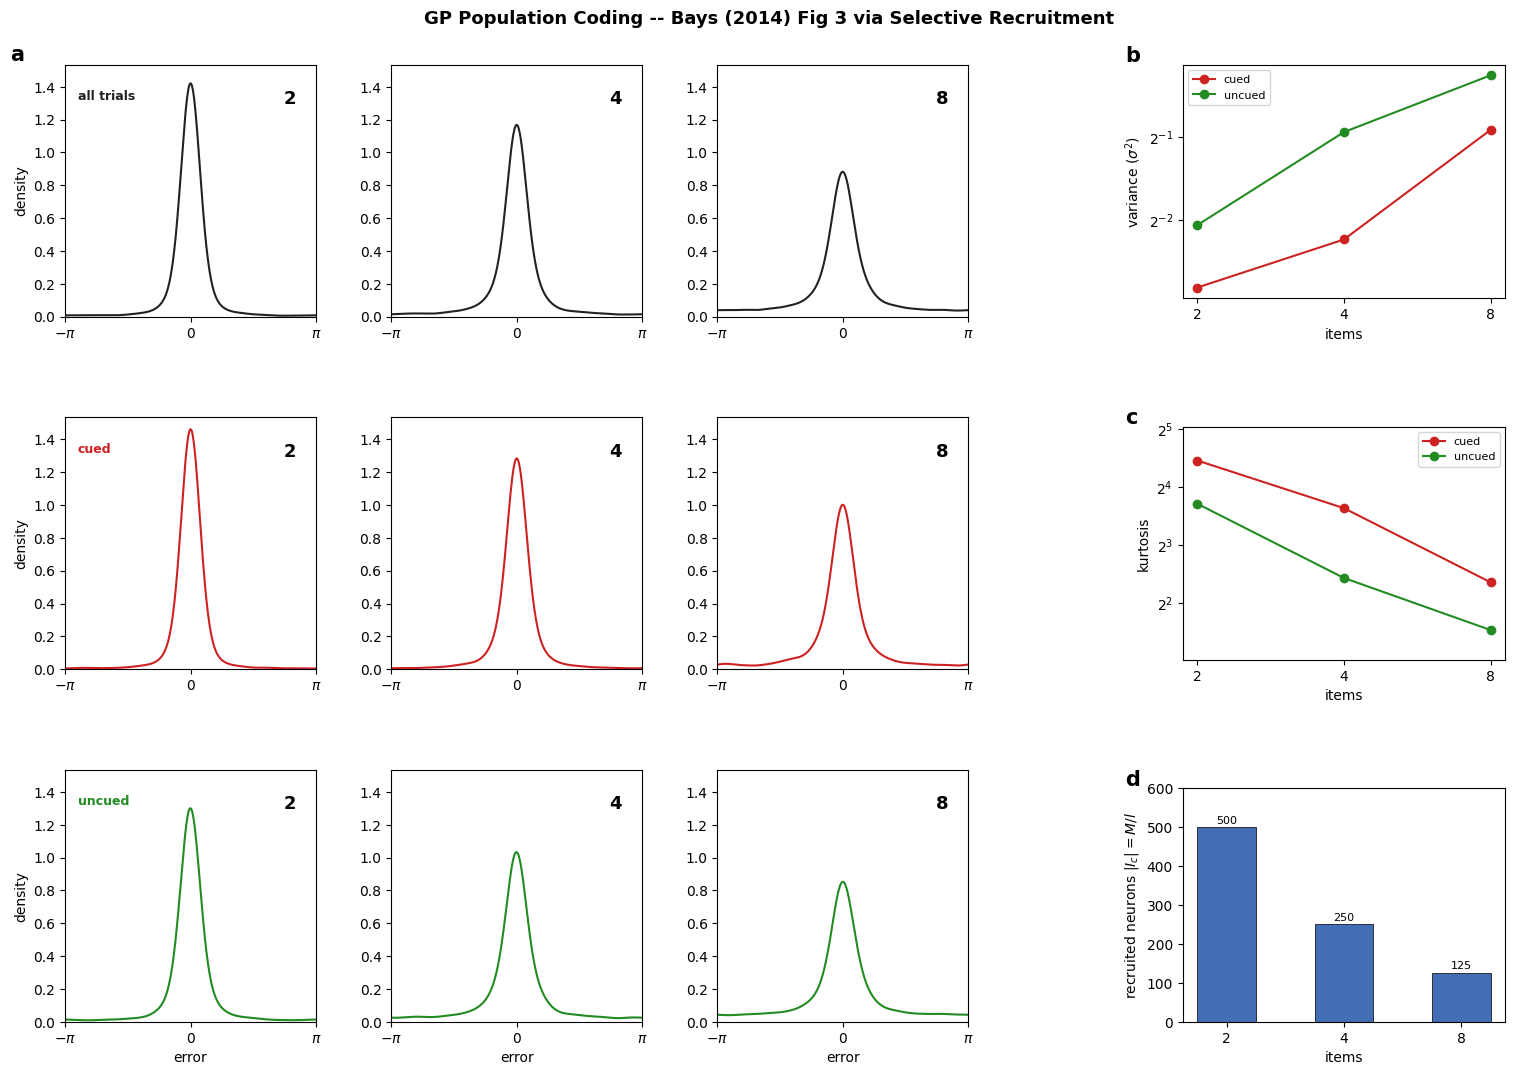

In [12]:
RED, GREEN, BLACK, BLUE = '#CC2222', '#228B22', '#222222', '#2255AA'
theta_smooth = np.linspace(-np.pi, np.pi, 500)

# Shared y-max for panel a
y_max = 0
for N in SET_SIZES:
    for k in ('err_all', 'err_cued', 'err_uncued'):
        d = vonmises_kde(summary[N][k], theta_smooth, KAPPA_KDE)
        y_max = max(y_max, d.max())
y_max *= 1.05

fig = plt.figure(figsize=(16, 11))
outer = gridspec.GridSpec(1, 2, width_ratios=[2.8, 1], wspace=0.35,
                          left=0.06, right=0.96, bottom=0.06, top=0.93)
gs_a   = gridspec.GridSpecFromSubplotSpec(3, len(SET_SIZES),
            subplot_spec=outer[0], hspace=0.4, wspace=0.3)
gs_bcd = gridspec.GridSpecFromSubplotSpec(3, 1,
            subplot_spec=outer[1], hspace=0.55)

# ---------- Panel a ----------
row_configs = [('err_all',    BLACK, 'all trials'),
               ('err_cued',   RED,   'cued'),
               ('err_uncued', GREEN, 'uncued')]
for row, (key, color, label) in enumerate(row_configs):
    for col, N in enumerate(SET_SIZES):
        ax = fig.add_subplot(gs_a[row, col])
        d = vonmises_kde(summary[N][key], theta_smooth, KAPPA_KDE)
        ax.plot(theta_smooth, d, color=color, lw=1.5)
        ax.set_xlim(-np.pi, np.pi); ax.set_ylim(0, y_max)
        ax.set_xticks([-np.pi, 0, np.pi])
        ax.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
        if row == 2: ax.set_xlabel('error')
        ax.text(0.92, 0.90, f'{N}', transform=ax.transAxes,
                fontsize=13, fontweight='bold', va='top', ha='right')
        if col == 0:
            ax.set_ylabel('density')
            ax.text(0.05, 0.90, label, transform=ax.transAxes,
                    fontsize=9, fontweight='bold', va='top', color=color)

fig.axes[0].text(-0.22, 1.08, r'$\mathbf{a}$', transform=fig.axes[0].transAxes,
                 fontsize=15, fontweight='bold', va='top')

ns = np.array(SET_SIZES, dtype=float)

# ---------- Panel b: variance ----------
ax_b = fig.add_subplot(gs_bcd[0])
vc = [summary[N]['vc'] for N in SET_SIZES]
vu = [summary[N]['vu'] for N in SET_SIZES]
ax_b.plot(ns, vc, 'o-', color=RED,   lw=1.5, ms=6, label='cued')
ax_b.plot(ns, vu, 'o-', color=GREEN, lw=1.5, ms=6, label='uncued')
ax_b.set_xscale('log', base=2); ax_b.set_yscale('log', base=2)
ax_b.set_xticks(SET_SIZES); ax_b.set_xticklabels([str(n) for n in SET_SIZES])
ax_b.set_xlabel('items'); ax_b.set_ylabel(r'variance ($\sigma^2$)')
ax_b.legend(fontsize=8, loc='upper left')
ax_b.text(-0.18, 1.08, r'$\mathbf{b}$', transform=ax_b.transAxes,
          fontsize=15, fontweight='bold', va='top')

# ---------- Panel c: kurtosis ----------
ax_c = fig.add_subplot(gs_bcd[1])
kc = [summary[N]['kc'] for N in SET_SIZES]
ku = [summary[N]['ku'] for N in SET_SIZES]
ax_c.plot(ns, kc, 'o-', color=RED,   lw=1.5, ms=6, label='cued')
ax_c.plot(ns, ku, 'o-', color=GREEN, lw=1.5, ms=6, label='uncued')
ax_c.set_xscale('log', base=2); ax_c.set_yscale('log', base=2)
ax_c.set_xticks(SET_SIZES); ax_c.set_xticklabels([str(n) for n in SET_SIZES])
all_k = [k for k in (kc + ku) if k > 0]
if all_k:
    ax_c.set_ylim(min(all_k) * 0.7, max(all_k) * 1.5)
ax_c.set_xlabel('items'); ax_c.set_ylabel('kurtosis')
ax_c.legend(fontsize=8, loc='upper right')
ax_c.text(-0.18, 1.08, r'$\mathbf{c}$', transform=ax_c.transAxes,
          fontsize=15, fontweight='bold', va='top')

# ---------- Panel d: recruitment count ----------
ax_d = fig.add_subplot(gs_bcd[2])
recruit_counts = [summary[N]['M_recruit'] for N in SET_SIZES]
bar_x = np.arange(len(SET_SIZES))
bars = ax_d.bar(bar_x, recruit_counts, 0.5,
                color=BLUE, alpha=0.85, edgecolor='k', lw=0.6)
for x, c in zip(bar_x, recruit_counts):
    ax_d.text(x, c + max(recruit_counts) * 0.02, f'{c}',
              ha='center', fontsize=8)
ax_d.set_xticks(bar_x); ax_d.set_xticklabels([str(n) for n in SET_SIZES])
ax_d.set_xlabel('items')
ax_d.set_ylabel(r'recruited neurons $|I_c| = M/l$')
ax_d.set_ylim(0, max(recruit_counts) * 1.2)
ax_d.text(-0.18, 1.08, r'$\mathbf{d}$', transform=ax_d.transAxes,
          fontsize=15, fontweight='bold', va='top')

fig.suptitle('GP Population Coding -- Bays (2014) Fig 3 via Selective Recruitment',
             fontsize=13, fontweight='bold')
plt.savefig('bays_fig3_recruitment.png', dpi=150, bbox_inches='tight')
plt.show()


## Discussion

**What the recruitment model preserves from the α model.**

1. **Cued precision exceeds uncued precision** at every set size. Different mechanism, same qualitative effect — a cued item is recalled more accurately than an uncued one. In the α model this came from gain modulation; here it comes from the recruited neurons being sharply tuned at the cued location and only randomly tuned at uncued locations.
2. **Variance grows with set size** for both cued and uncued. The recruitment model has *two* drivers for this: (i) per-item activity reduction within DN (γM/l divided across l items), and (ii) the recruited subpopulation itself shrinking as M/l. Both work in the same direction.
3. **Positive kurtosis everywhere** — the system is in a low-SNR Poisson regime where decoded distributions deviate from circular normal in the characteristic peaked-with-heavy-tails way Bays reported.

**What the recruitment model gives up.**

1. **No optimisable α.** The previous notebook's Panel d (optimal α* per set size) is gone — there is no continuous attention strength to optimise. The "attention budget" is the fixed M/l recruitment count, set entirely by l. If you want a tunable budget, you'd promote the recruitment fraction to a free parameter ρ ∈ (0, 1] and re-introduce a sweep over it.
2. **Mixed selectivity is no longer the load-bearing part of the story.** The previous framework's central claim was that DN over a richly mixed-selective population produces capacity from competition. Here, the capacity-shaping work is done by *which* neurons are active for the trial. Mixed selectivity still helps (recruited neurons still encode all locations), but it isn't the main mechanism anymore.

**What the recruitment model predicts that gain modulation does not.**

1. **Uncued errors should be roughly cue-independent in distribution shape.** Under recruitment, uncued items are decoded by a population that was selected for being sharp at the cued location — so from the uncued items' perspective, they are being read out by an *essentially random* subpopulation. This predicts uncued error distributions should look similar regardless of which location was cued (modulo finite-sample noise). Gain modulation predicts uncued errors depend on the spatial relationship between the cue and the uncued item, since DN couples them.
2. **A floor on uncued precision that doesn't go to zero with extreme attention.** Even if you push attention to its sharpest possible setting (say, recruit only one neuron), the uncued items are still encoded by *that one neuron*'s tuning at uncued locations, which is whatever it happens to be — not zero. Under gain modulation, pushing α to infinity does drive uncued precision to zero through the DN denominator. So the two models diverge at the high-attention extreme.
3. **A discrete-population signature in uncued errors.** Because uncued items are encoded by the same fixed M/l neurons across all trials at a given set size, the uncued error distribution should reflect the specific tuning curves of that subpopulation — potentially with structure (skews, lobes) that wouldn't appear under gain modulation. Worth looking at the uncued distributions in panel a for any such structure.

The biological story has shifted from "attention is a multiplicative gain on the cued contribution" to "attention selects which neurons participate in working memory at all" — biased competition rather than gain modulation. Both are documented in the attention literature; this notebook is the recruitment-side instantiation in the GP framework.




## Implementation notes (soft-gain version)

Three things worth knowing about this version of the notebook.

**1. The max-subtraction trick still works.** After scaling, the per-trial argmax of `r_pre` may belong to a different (recruited) neuron than it did before scaling. That's fine: max-subtraction happens *before* the scaling step (`subtract max → exp → scale by ALPHA → DN`), so the quantity being subtracted is still a per-trial scalar that factors cleanly out of both numerator and denominator of DN. The order matters only for floating-point conditioning, not for the math — scaling before subtracting would give the identical post-DN result because $\alpha$ is a per-neuron constant and pulls through.

**2. `ALPHA = 10.0` is a starting guess, not a fitted value.** With $M = 1000$ and $|I_c|$ ranging from 125 to 500, the recruited fraction is 12.5–50%. For the recruited subpopulation to dominate the DN denominator, you need roughly $\alpha \cdot M_{\text{recruit}} \gg M - M_{\text{recruit}}$, i.e., $\alpha \gg l - 1$. So $\alpha = 10$ is comfortably above that at $l = 2$ (need $\alpha \gg 1$) and just above at $l = 8$ (need $\alpha \gg 7$). If cued/uncued separation looks weak at $l = 8$, push $\alpha$ to 30 or 100. If you want to sweep, log-space values $\{1, 3, 10, 30, 100\}$ would be a sensible first pass.

**3. Sanity check at $\alpha = 1$.** Set `ALPHA = 1.0` and rerun. Cued and uncued variances should come out essentially equal — the recruited mask is being computed but has no behavioural consequence. If a meaningful cued/uncued gap appears at $\alpha = 1$, something is wrong (most likely a probe-location asymmetry between location 0 and the uncued locations $\{1, \ldots, l-1\}$, since the GP draws at each location are independent). This is the cheapest validation to run before any parameter sweep.

**4. What changed from the previous (hard-mask) notebook.** Both pipelines select the same top-$M/l$ neurons by sharpness at location 0. The differences are:

| | Hard mask (v1) | Soft gain (this notebook) |
|---|---|---|
| $r^{\text{pre}}$ computed over | recruited only ($M/l$ neurons) | full population ($M$ neurons) |
| Non-recruited contribution | 0 (silent) | $\times 1$ (unscaled) |
| Recruited contribution | $\times 1$ | $\times \alpha$ |
| DN denominator averages over | $M/l$ | $M$ |
| Decoder sees spikes from | $M/l$ neurons | all $M$ neurons |
| Free parameter | none | $\alpha$ |
| Hard-mask is recovered when | (this is it) | $\alpha \to \infty$ |

Holding $\gamma$ fixed, the post-DN rate per recruited neuron is roughly $l \times$ smaller in this notebook than in the hard-mask version, because the denominator now averages over $l \times$ more neurons. Variance magnitudes are therefore not directly comparable across the two notebooks — only the cued/uncued *ratio* and qualitative scaling with $l$ are.
